In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns


In [32]:
df=pd.read_csv("cc_approvals.data",header=None)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,00260,0,-
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,00200,394,-
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,00200,1,-
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,00280,750,-


In [33]:
#Gender, Age, Debt, Married, BankCustomer, EducationLevel, Ethnicity, YearsEmployed, PriorDefault, 
#Employed, CreditScore, DriversLicense, Citizen, ZipCode, Income, ApprovalStatus

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    object 
 1   1       690 non-null    object 
 2   2       690 non-null    float64
 3   3       690 non-null    object 
 4   4       690 non-null    object 
 5   5       690 non-null    object 
 6   6       690 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      690 non-null    object 
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


In [35]:
df.columns=['Gender', 'Age', 'Debt', 'Married', 'BankCustomer', 'EducationLevel','Ethnicity', 'YearsEmployed', 'PriorDefault', 'Employed', 
            'CreditScore', 'DriversLicense', 'Citizen', 'ZipCode', 'Income', 'ApprovalStatus']

In [36]:
df.describe()

,Debt,YearsEmployed,CreditScore,Income
count,690.000000,690.000000,690.00000,690.000000
mean,4.758725,2.223406,2.40000,1017.385507
std,4.978163,3.346513,4.86294,5210.102598
min,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.165000,0.00000,0.000000
50%,2.750000,1.000000,0.00000,5.000000
75%,7.207500,2.625000,3.00000,395.500000
max,28.000000,28.500000,67.00000,100000.000000


In [43]:
print(df['Gender'].unique())
print(df['Gender'].value_counts())

['b' 'a' '?']
Gender
b    468
a    210
?     12
Name: count, dtype: int64


In [44]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
categorical_cols=df.select_dtypes(include="object").columns
for col in categorical_cols:
    df[col] =le.fit_transform(df[col].astype(str))

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.isnull().sum()

Gender            0
Age               0
Debt              0
Married           0
BankCustomer      0
EducationLevel    0
Ethnicity         0
YearsEmployed     0
PriorDefault      0
Employed          0
CreditScore       0
DriversLicense    0
Citizen           0
ZipCode           0
Income            0
ApprovalStatus    0
dtype: int64

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    int64  
 1   Age             690 non-null    int64  
 2   Debt            690 non-null    float64
 3   Married         690 non-null    int64  
 4   BankCustomer    690 non-null    int64  
 5   EducationLevel  690 non-null    int64  
 6   Ethnicity       690 non-null    int64  
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    int64  
 9   Employed        690 non-null    int64  
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    int64  
 12  Citizen         690 non-null    int64  
 13  ZipCode         690 non-null    int64  
 14  Income          690 non-null    int64  
 15  ApprovalStatus  690 non-null    int64  
dtypes: float64(2), int64(14)
memory usage: 86.4 KB


In [48]:
df.sample(5)

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,ApprovalStatus
281,2,84,0.585,3,3,3,4,0.125,0,0,0,0,0,84,1,1
234,1,326,21.000,2,1,7,1,10.000,1,1,13,0,0,0,6700,0
341,2,256,4.085,2,1,1,8,0.040,0,0,0,0,0,33,100,1
284,2,78,12.625,2,1,2,8,0.125,0,1,2,0,0,0,5552,1
635,2,23,2.460,2,1,2,6,0.960,0,1,2,1,0,52,587,1


In [49]:
df.corr()

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,ApprovalStatus
Gender,1.000000,0.055999,-0.013967,0.044990,0.047057,0.004854,0.062229,0.099863,0.025241,-0.045808,0.006799,0.052396,0.058113,0.059978,0.008504,-0.000648
Age,0.055999,1.000000,0.135058,-0.068214,-0.085631,0.026752,-0.190155,0.386076,0.197493,0.047300,0.160599,0.079829,0.001284,-0.001211,0.016829,-0.133304
Debt,-0.013967,0.135058,1.000000,-0.047608,-0.068773,0.027622,-0.016451,0.298902,0.244317,0.174846,0.271207,-0.013023,-0.122233,-0.262772,0.123121,-0.206294
Married,0.044990,-0.068214,-0.047608,1.000000,0.942463,0.011832,0.063158,-0.048423,-0.078851,-0.114926,-0.077948,0.029057,-0.094585,-0.091238,-0.101102,0.191431
BankCustomer,0.047057,-0.085631,-0.068773,0.942463,1.000000,-0.038876,-0.003989,-0.065497,-0.129863,-0.162464,-0.106457,0.015342,-0.036095,-0.018734,-0.022904,0.187520
EducationLevel,0.004854,0.026752,0.027622,0.011832,-0.038876,1.000000,0.057192,0.040598,0.113752,0.132744,0.009907,0.077824,-0.018090,0.066057,0.005907,-0.129398
Ethnicity,0.062229,-0.190155,-0.016451,0.063158,-0.003989,0.057192,1.000000,-0.074281,-0.002135,0.032440,-0.015461,0.020007,-0.016338,-0.064167,-0.009131,-0.000877
YearsEmployed,0.099863,0.386076,0.298902,-0.048423,-0.065497,0.040598,-0.074281,1.000000,0.345689,0.222982,0.322330,0.138139,-0.020528,-0.106919,0.051345,-0.322475
PriorDefault,0.025241,0.197493,0.244317,-0.078851,-0.129863,0.113752,-0.002135,0.345689,1.000000,0.432032,0.379532,0.091276,-0.113623,-0.096796,0.090012,-0.720407
Employed,-0.045808,0.047300,0.174846,-0.114926,-0.162464,0.132744,0.032440,0.222982,0.432032,1.000000,0.571498,0.017043,-0.242568,-0.091529,0.077652,-0.458301


<Axes: >

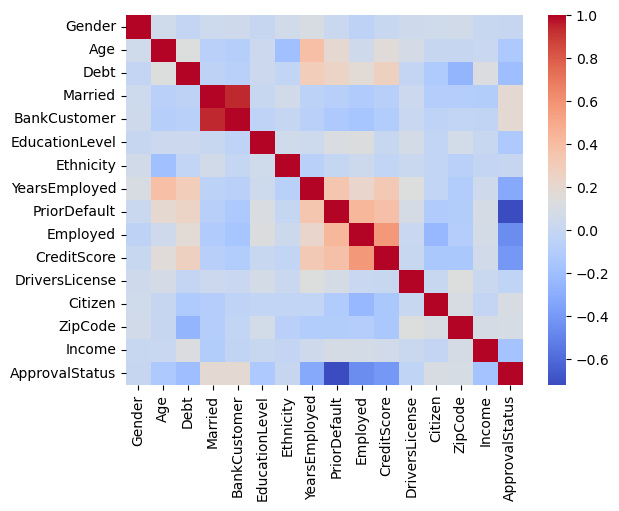

In [50]:
sns.heatmap(df.corr(),cmap='coolwarm')

In [51]:
#employed and creditscore are related
#years employed and age age are related
#prior default is related with approval status such that its inversely related
#ethnicity,driverslicense,citizen,zipcode are irrelevant columns
#Gender should also be irrelevant but I will keep it to see some graphs

In [52]:
df.drop(columns=["Ethnicity","DriversLicense","Citizen","ZipCode"],inplace=True)

In [53]:
df

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,YearsEmployed,PriorDefault,Employed,CreditScore,Income,ApprovalStatus
0,2,156,0.000,2,1,13,1.25,1,1,1,0,0
1,1,328,4.460,2,1,11,3.04,1,1,6,560,0
2,1,89,0.500,2,1,11,1.50,1,0,0,824,0
3,2,125,1.540,2,1,13,3.75,1,1,5,3,0
4,2,43,5.625,2,1,13,1.71,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
685,2,52,10.085,3,3,5,1.25,0,0,0,0,1
686,1,71,0.750,2,1,2,2.00,0,1,2,394,1
687,1,97,13.500,3,3,6,2.00,0,1,1,1,1
688,2,20,0.205,2,1,1,0.04,0,0,0,750,1


<Axes: ylabel='count'>

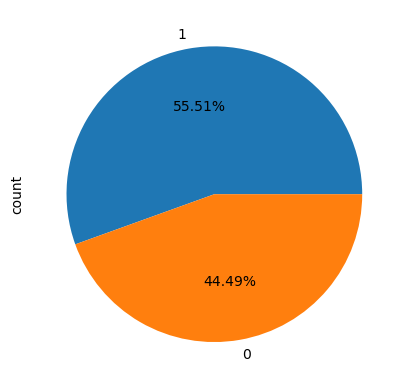

In [54]:
df["ApprovalStatus"].value_counts().plot(kind="pie",autopct="%0.2f%%")

Text(0, 0.5, 'Count')

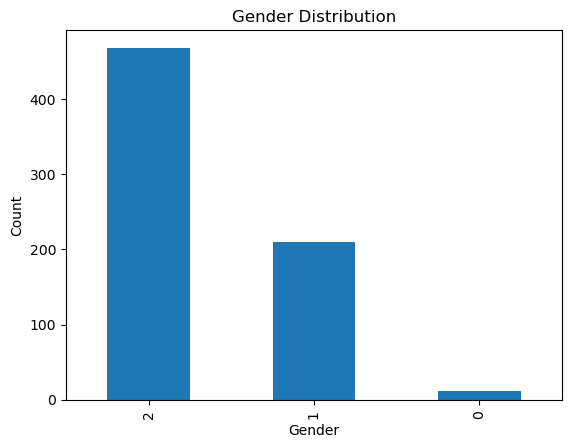

In [29]:
df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

<Axes: >

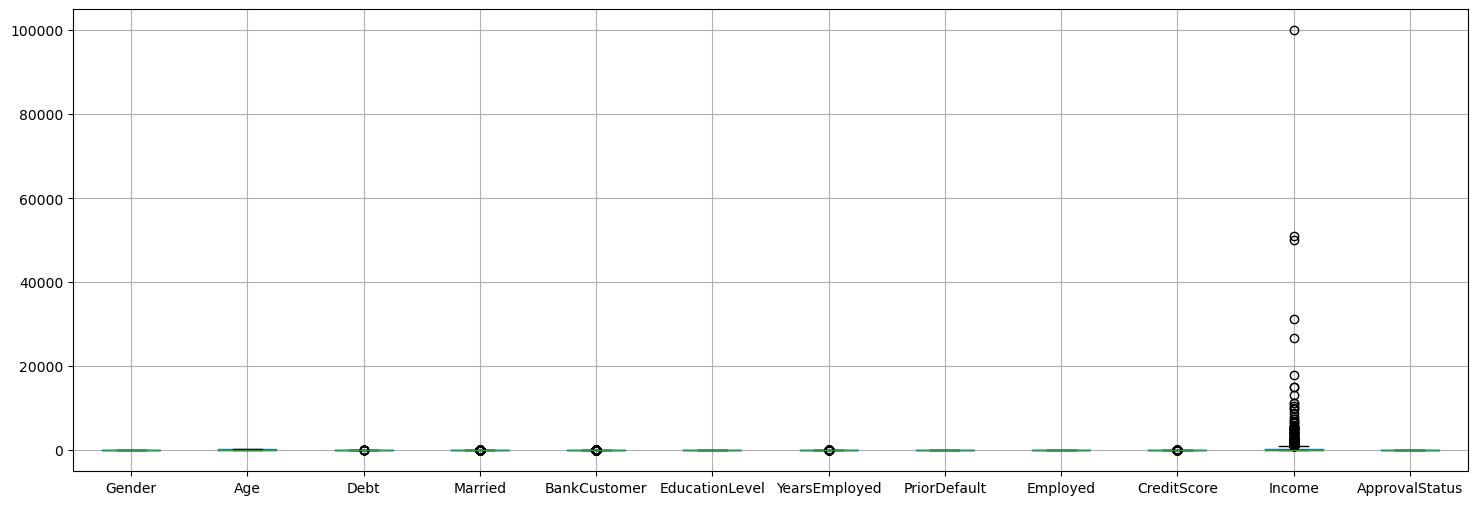

In [56]:
df.boxplot(figsize=(18,6))

In [63]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['ApprovalStatus'])
y=df['ApprovalStatus']
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [64]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [65]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [67]:
y_pred=lr.predict(X_test_scaled)

In [68]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(y_test,y_pred)
acc

0.8478260869565217

In [69]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[59 11]
 [10 58]]


In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85        70
           1       0.84      0.85      0.85        68

    accuracy                           0.85       138
   macro avg       0.85      0.85      0.85       138
weighted avg       0.85      0.85      0.85       138



In [73]:
print(lr.coef_)

[[ 0.13084674  0.05709613  0.07919711  1.17858801 -0.70861603 -0.19446755
  -0.30429315 -1.88470474 -0.32753166 -0.4699945  -1.94187736]]


In [76]:
accuracy_score(y_train,lr.predict(X_train_scaled))

0.8840579710144928

In [77]:
#Model DOESNT seem to be overfit or underfit
#APPLYING GridSearchCV

In [88]:
from sklearn.model_selection import GridSearchCV
lr=LogisticRegression(max_iter=1000)
param_grid={
    "C":[0.01,0.1,1,10,100,125],
    "solver":["lbfgs",'liblinear'],
    'penalty':['l2']}
grid=GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1)

In [92]:
import time
start=time.time()
grid.fit(X_train,y_train)
print(grid.best_params_)
print(time.time()-start)
print(grid.best_score_)

{'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
1.4653124809265137
0.8730876330876332


C:\Users\surya\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [93]:
best_model=grid.best_estimator_
y_pred=best_model.predict(X_test_scaled)

C:\Users\surya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [94]:
accuracy_score(y_test,y_pred)

0.8333333333333334